In [227]:
#!pip install medmnist

In [228]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import torch.nn.functional as F

import medmnist
from medmnist import INFO, Evaluator

In [229]:
print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")

MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/


# We work on the 2D dataset with size 28x28

In [230]:
data_flag = 'bloodmnist'
download = True
BATCH_SIZE = 128

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

## First, we read the MedMNIST data, preprocess them and encapsulate them into dataloader form.

In [231]:
# preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

pil_dataset = DataClass(split='train', download=download)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [232]:
print(train_dataset)
print("===================")
print(test_dataset)

Dataset BloodMNIST of size 28 (bloodmnist)
    Number of datapoints: 11959
    Root location: C:\Users\alexk\.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
    Number of samples: {'train': 11959, 'val': 1712, 'test': 3421}
    Description: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
    Lice

In [233]:
# visualization

train_dataset.montage(length=1)



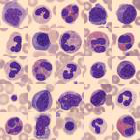

In [234]:

train_dataset.montage(length=5)

In [235]:
#Access a single image / label
image, label = train_dataset[2]  # image is a tensor , label is an  int
print("Shape da imagem:", image.shape)
print("Classe:", label)

# Convert to NumPy array
image_array = image.numpy()
print("Size:", image_array.shape )

#Access a subset of images
img = train_dataset[1][0].numpy   # image
lab = train_dataset[1][1]   # label
start_idx = 10
end_idx = 20  # exclusive
images_array = np.stack([train_dataset[i][0].numpy() for i in range(start_idx, end_idx)])
labels_array = np.array([train_dataset[i][1] for i in range(start_idx, end_idx)])

print("Size:", images_array.shape )
print(labels_array)




Shape da imagem: torch.Size([3, 28, 28])
Classe: [6]
Size: (3, 28, 28)
Size: (10, 3, 28, 28)
[[1]
 [1]
 [6]
 [7]
 [6]
 [3]
 [7]
 [2]
 [6]
 [1]]


DEFINING THE MODEL

In [236]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16) # same as out_channels
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3, padding =1)
        self.bn1 = nn.BatchNorm2d(32) # Matches out_channels
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64) # Matches out_channels
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
    
        self.flatten = nn.Flatten()
        
        self.dense = nn.Linear(64 * 3 * 3, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.0) # drops % neurons
        self.output = nn.Linear(128, 8)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.relu(self.conv3(x))
        x = self.pool3(x)
        x = self.flatten(x)
        x = self.dropout(self.relu(self.dense(x)))
        x = self.output(x)
        #return F.log_softmax(x, dim=1)
        return x

EARLY STOPPING

In [237]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0

    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)

SET UP

In [238]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
#criterion = nn.NLLLoss()

#optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = torch.optim.SGD(model.parameters(), lr=0.003, momentum=0.9)

early_stopping = EarlyStopping(patience=20, delta=0.01)

TRAINING LOOP  + VALIDATION

In [239]:
val_dataset = DataClass(split='val', transform=data_transform, download=download)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=2*BATCH_SIZE, shuffle=True)

In [240]:
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for data, labels in train_loader:
        data = data.to(device)
        labels = labels.squeeze().long().to(device)  # important for CrossEntropyLoss

        optimizer.zero_grad()

        outputs = model(data)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    valid_loss = 0.0
    model.eval()
    for data, labels in val_loader:
        data = data.to(device)
        labels = labels.squeeze().long().to(device)
        
        # Forward Pass
        target = model(data)
        # Find the Loss
        loss = criterion(target,labels)
        # Calculate Loss
        valid_loss += loss.item()

    print(f"Epoch {epoch + 1}\t\tTraining Loss: {epoch_loss / len(train_loader):.4f}\t\tValidation Loss: {valid_loss / len(val_loader):.4f}")

    early_stopping(valid_loss, model)
    if early_stopping.early_stop:
        print("Early stopping")
        break
    
    early_stopping.load_best_model(model)

Epoch 1		Training Loss: 2.0389		Validation Loss: 2.0007
Epoch 2		Training Loss: 1.9990		Validation Loss: 1.9961
Epoch 3		Training Loss: 1.9888		Validation Loss: 1.9808
Epoch 4		Training Loss: 1.9571		Validation Loss: 1.9164
Epoch 5		Training Loss: 1.7343		Validation Loss: 1.5003
Epoch 6		Training Loss: 1.3450		Validation Loss: 1.3021
Epoch 7		Training Loss: 1.1135		Validation Loss: 0.9709
Epoch 8		Training Loss: 0.9725		Validation Loss: 0.8781
Epoch 9		Training Loss: 0.8868		Validation Loss: 0.8885
Epoch 10		Training Loss: 0.8303		Validation Loss: 0.7845
Epoch 11		Training Loss: 0.7944		Validation Loss: 0.7700
Epoch 12		Training Loss: 0.7931		Validation Loss: 0.7184
Epoch 13		Training Loss: 0.7535		Validation Loss: 0.7068
Epoch 14		Training Loss: 0.7167		Validation Loss: 0.7264
Epoch 15		Training Loss: 0.6865		Validation Loss: 0.6444
Epoch 16		Training Loss: 0.6604		Validation Loss: 0.6649
Epoch 17		Training Loss: 0.6693		Validation Loss: 0.6310
Epoch 18		Training Loss: 0.6344		Validat

EVALUATION

In [241]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy on test set: {accuracy:.2f}%')

Accuracy on test set: 89.56%


MLP 

In [242]:
class MLP:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = torch.randn(input_size, hidden_size, requires_grad=True)
        self.b1 = torch.randn(1, hidden_size, requires_grad=True)
        self.W2 = torch.randn(hidden_size, output_size, requires_grad=True)
        self.b2 = torch.randn(1, output_size, requires_grad=True)

    def forward(self, X):
        self.z1 = torch.matmul(X, self.W1) + self.b1
        self.a1 = torch.sigmoid(self.z1)  # Hidden layer activation
        self.z2 = torch.matmul(self.a1, self.W2) + self.b2
        self.a2 = torch.sigmoid(self.z2)  # Output layer activation
        return self.a2